# 📊 EDA on Retail Sales Data
**Oasis Infobyte SIP — Data Analytics Track — Level 1, Task 1**

**Objective:** Perform a thorough Exploratory Data Analysis on a retail sales dataset to uncover patterns, customer behaviour trends, and actionable business insights.

**Dataset:** [Superstore Dataset](https://www.kaggle.com/datasets/vivek468/superstore-dataset-final) (Kaggle) — 9,994 real orders from a US superstore, spanning 2014–2017, with 21 columns covering order/shipping details, customer segment, geography, product category, sales, quantity, discount, and profit.

> 📝 **Note on demographics:** This dataset does not include individual customer age or gender — only `Segment` (Consumer / Corporate / Home Office), `Ship Mode`, and geography (`Region`, `State`, `City`) describe the customer base. Rather than fabricate age/gender data that doesn't exist in the source, the demographics section below analyses the customer attributes that are genuinely present.

## 1. Setup & Data Loading

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('Sample - Superstore.csv', encoding='latin1', parse_dates=['Order Date', 'Ship Date'])
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [16]:
print("Shape:", df.shape)
print("\nColumn dtypes:")
print(df.dtypes)


Shape: (9994, 21)

Column dtypes:
Row ID                    int64
Order ID                 object
Order Date       datetime64[ns]
Ship Date        datetime64[ns]
Ship Mode                object
Customer ID              object
Customer Name            object
Segment                  object
Country                  object
City                     object
State                    object
Postal Code               int64
Region                   object
Product ID               object
Category                 object
Sub-Category             object
Product Name             object
Sales                   float64
Quantity                  int64
Discount                float64
Profit                  float64
dtype: object


In [17]:
print("Null values per column:")
print(df.isnull().sum())
print(f"\nTotal null cells: {df.isnull().sum().sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")


Null values per column:
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

Total null cells: 0
Duplicate rows: 0


**Observation:** The dataset is remarkably clean — **zero missing values** across all 21 columns and **zero duplicate rows**. This is a well-prepared, analysis-ready dataset with 9,994 orders spanning January 2014 to December 2017 (4 full years).

## 2. Descriptive Statistics

In [18]:
numeric_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
desc = df[numeric_cols].describe().T
desc['median'] = df[numeric_cols].median()
desc[['mean', 'median', 'std', 'min', 'max']]


,mean,median,std,min,max
Sales,229.858001,54.4900,623.245101,0.444,22638.480
Quantity,3.789574,3.0000,2.225110,1.000,14.000
Discount,0.156203,0.2000,0.206452,0.000,0.800
Profit,28.656896,8.6665,234.260108,-6599.978,8399.976


**Observation:** Average order value (`Sales`) is **$229.86**, but the median is far lower at **$54.49** — a heavily right-skewed distribution, driven by a small number of very large orders (max order: $22,638.48, a Cisco videoconferencing unit). Average profit per order is **$28.66**, but the range is extreme: from a **loss of -$6,599.98** to a **gain of $8,399.98** — meaning some individual transactions are extremely unprofitable.

## 3. Time Series Analysis — Monthly & Quarterly Sales Trends

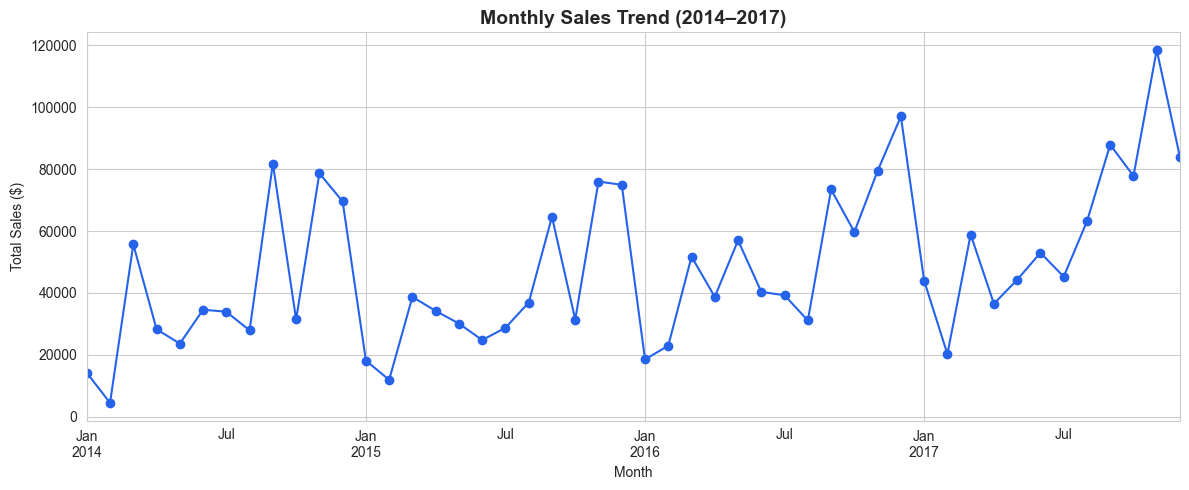

In [19]:
df['Month'] = df['Order Date'].dt.to_period('M').dt.to_timestamp()
df['Quarter'] = df['Order Date'].dt.to_period('Q').astype(str)

monthly_sales = df.groupby('Month')['Sales'].sum()

fig, ax = plt.subplots(figsize=(12, 5))
monthly_sales.plot(ax=ax, marker='o', linewidth=1.5, color='#2563eb')
ax.set_title('Monthly Sales Trend (2014–2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Total Sales ($)')
plt.tight_layout()
plt.show()


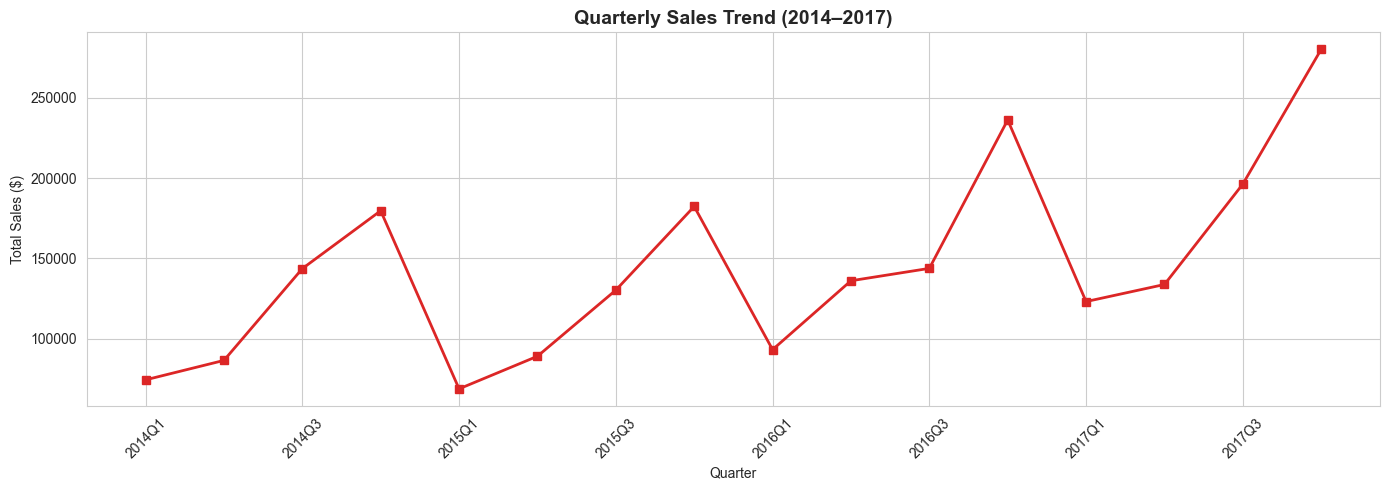

In [20]:
quarterly_sales = df.groupby('Quarter')['Sales'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
quarterly_sales.plot(kind='line', ax=ax, marker='s', linewidth=2, color='#dc2626')
ax.set_title('Quarterly Sales Trend (2014–2017)', fontsize=14, fontweight='bold')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


**Observation:** There's a clear **upward growth trend and strong seasonality**. Monthly sales range from as low as **$4,520** to as high as **$118,448**. At the quarterly level, the **top 3 quarters are all Q4/Q3 of the later years — 2017 Q4 ($280,054), 2016 Q4 ($236,099), and 2017 Q3 ($196,252)** — while the weakest quarters are early years' Q1 (**2015 Q1: $68,852, 2014 Q1: $74,448**). This is a classic **Q4 holiday-driven retail pattern**, combined with genuine year-over-year growth.

## 4. Customer Segment & Fulfillment Analysis
*(Substituting for age/gender demographics, which aren't present in this dataset — see note above.)*

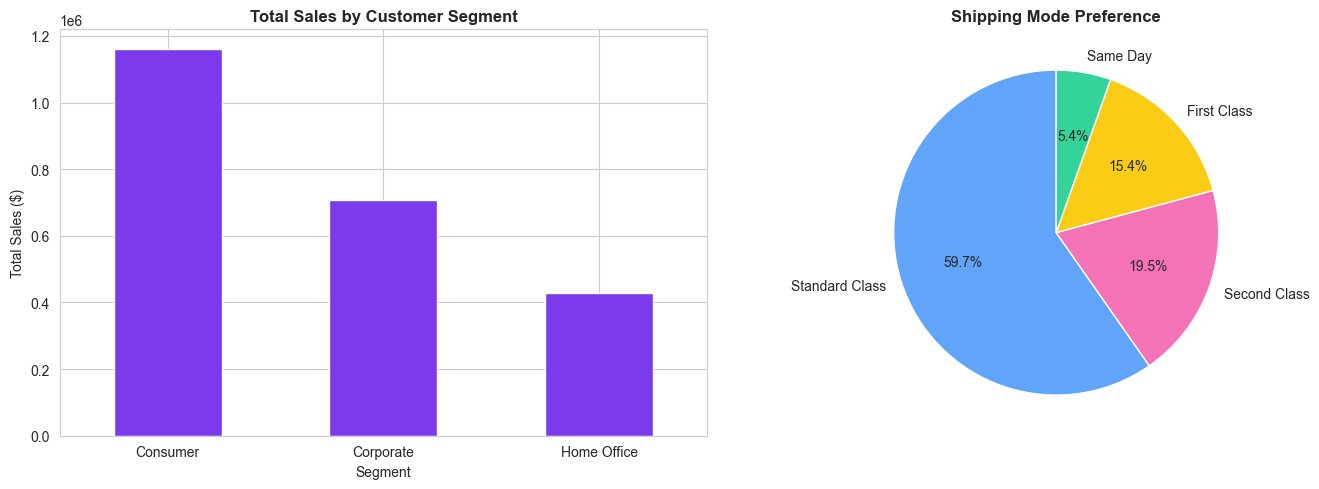

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

segment_sales = df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
segment_sales.plot(kind='bar', ax=axes[0], color='#7c3aed')
axes[0].set_title('Total Sales by Customer Segment', fontweight='bold')
axes[0].set_ylabel('Total Sales ($)')
axes[0].tick_params(axis='x', rotation=0)

ship_counts = df['Ship Mode'].value_counts()
axes[1].pie(ship_counts, labels=ship_counts.index, autopct='%1.1f%%',
            colors=['#60a5fa', '#f472b6', '#facc15', '#34d399'], startangle=90)
axes[1].set_title('Shipping Mode Preference', fontweight='bold')

plt.tight_layout()
plt.show()


**Observation:** The **Consumer segment** dominates revenue at **$1,161,401** — more than the Corporate ($706,146) and Home Office ($429,653) segments combined. On fulfillment, **nearly 60% of orders (59.7%) use Standard Class shipping**, with only **5.4% choosing Same Day** delivery — most customers are not paying a premium for speed, suggesting price sensitivity is a stronger purchase driver than delivery urgency for this customer base.

## 5. Product Analysis

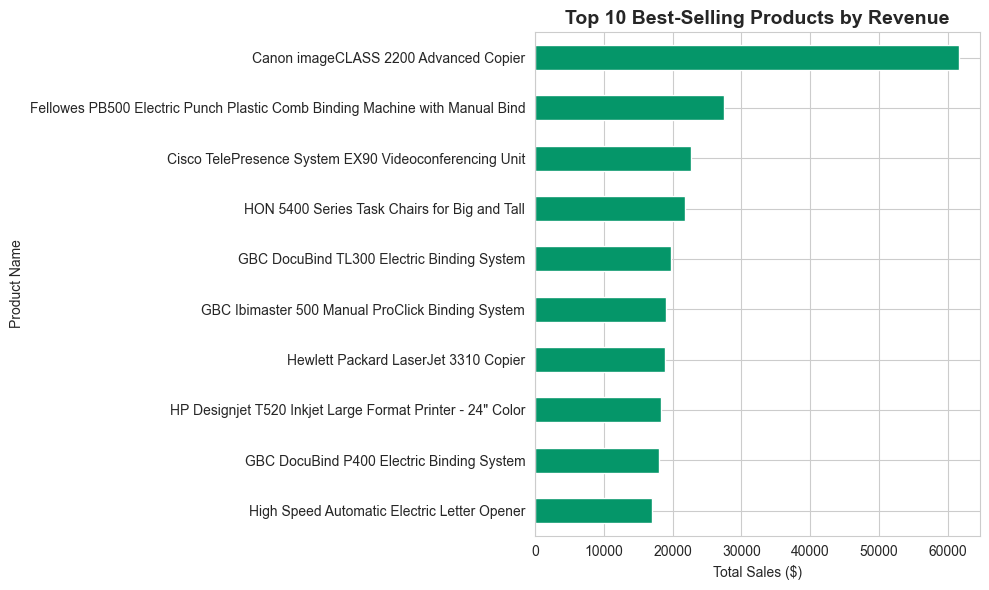

In [22]:
top10_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 6))
top10_products.sort_values().plot(kind='barh', ax=ax, color='#059669')
ax.set_title('Top 10 Best-Selling Products by Revenue', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Sales ($)')
plt.tight_layout()
plt.show()


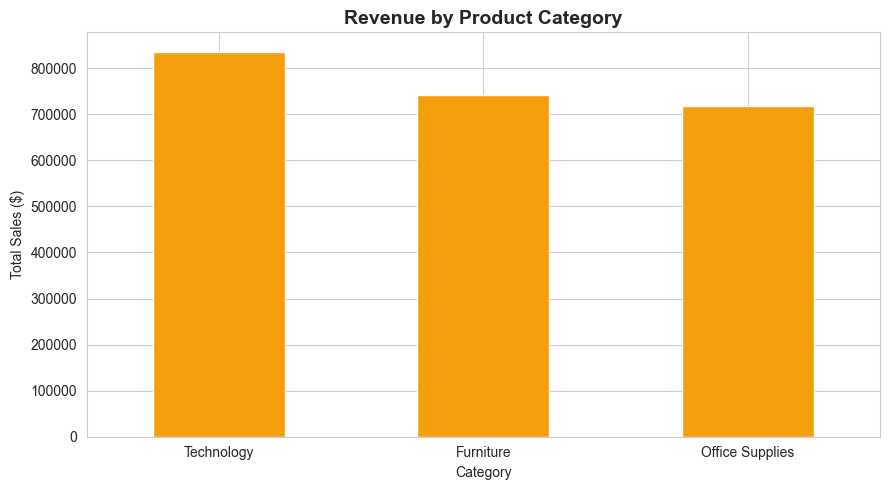

In [23]:
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
category_revenue.plot(kind='bar', ax=ax, color='#f59e0b')
ax.set_title('Revenue by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Category')
ax.set_ylabel('Total Sales ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


**Observation:** The single best-selling product is the **Canon imageCLASS 2200 Advanced Copier ($61,600)** — more than double the next highest item. At the category level, revenue is fairly evenly split: **Technology ($836,154), Furniture ($742,000), and Office Supplies ($719,047)** — no single category dominates, unlike many retail datasets. This balance suggests the business isn't overexposed to any one product line.

## 6. Correlation Heatmap

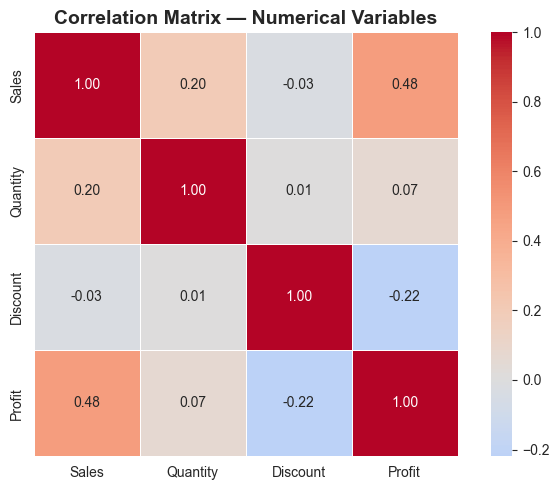

In [24]:
corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax)
ax.set_title('Correlation Matrix — Numerical Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


**Observation:** `Sales` and `Profit` are moderately positively correlated (**r = 0.48**) — larger orders tend to be more profitable, but far from guaranteed. The standout relationship is `Discount` vs `Profit` at **r = -0.22**: a clear negative relationship. `Quantity` barely correlates with `Profit` (r = 0.07), showing that **selling more units doesn't reliably drive profit — pricing and discounting strategy matters far more than volume.**

## 7. Additional Insight — How Much Does Discounting Destroy Profit?

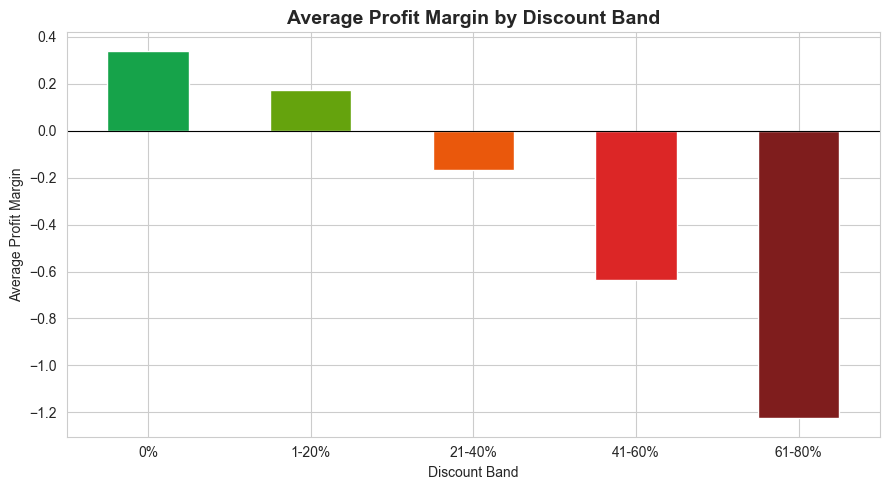

In [25]:
df['Profit_Margin'] = df['Profit'] / df['Sales']
discount_bins = pd.cut(df['Discount'], bins=[-0.01, 0, 0.2, 0.4, 0.6, 0.9],
                        labels=['0%', '1-20%', '21-40%', '41-60%', '61-80%'])
margin_by_discount = df.groupby(discount_bins, observed=True)['Profit_Margin'].mean()

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#16a34a', '#65a30d', '#ea580c', '#dc2626', '#7f1d1d']
margin_by_discount.plot(kind='bar', ax=ax, color=colors)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('Average Profit Margin by Discount Band', fontsize=14, fontweight='bold')
ax.set_ylabel('Average Profit Margin')
ax.set_xlabel('Discount Band')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


In [26]:
neg_profit = df[df['Profit'] < 0]
pct_neg = len(neg_profit) / len(df) * 100
print(f"Orders sold at a loss: {len(neg_profit)} out of {len(df)} ({pct_neg:.1f}%)")
print(f"Total losses from these orders: ${neg_profit['Profit'].sum():,.2f}")


Orders sold at a loss: 1871 out of 9994 (18.7%)
Total losses from these orders: $-156,131.29


**Observation (this is the sharpest, most actionable finding in the dataset):** Average profit margin is a healthy **34% with no discount**, but flips **negative once discount exceeds 20%** — dropping to **-17% at 21-40% off**, **-63% at 41-60% off**, and a catastrophic **-123% at 61-80% off**. Overall, **1,871 orders (18.7% of all orders) were sold at an outright loss**, totalling **-$156,131** in losses. This single pattern — deep discounting — is very likely the single biggest lever available to improve overall company profitability.

## 8. Bonus: Regional Performance & Loss-Making Sub-Categories

In [27]:
region_perf = df.groupby('Region').agg(
    Total_Sales=('Sales', 'sum'),
    Avg_Order_Value=('Sales', 'mean'),
    Total_Profit=('Profit', 'sum')
).sort_values('Total_Sales', ascending=False)

region_perf


,Total_Sales,Avg_Order_Value,Total_Profit
Region,,,
West,725457.8245,226.493233,108418.4489
East,678781.2400,238.336110,91522.7800
Central,501239.8908,215.772661,39706.3625
South,391721.9050,241.803645,46749.4303


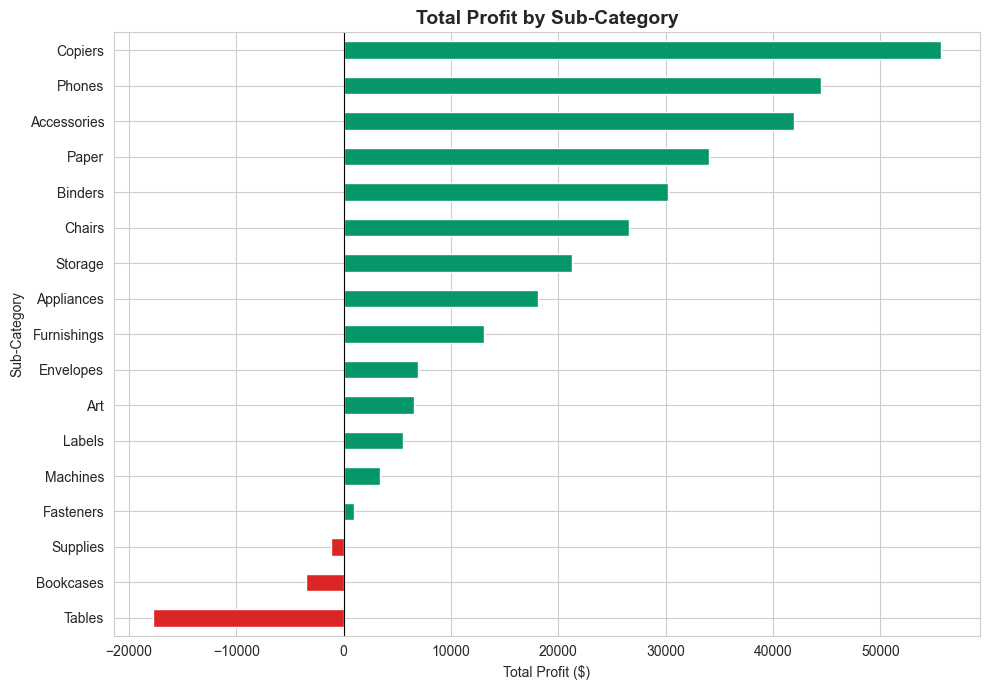

In [28]:
subcat_profit = df.groupby('Sub-Category')['Profit'].sum().sort_values()

fig, ax = plt.subplots(figsize=(10, 7))
colors = ['#dc2626' if v < 0 else '#059669' for v in subcat_profit.values]
subcat_profit.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Total Profit by Sub-Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Total Profit ($)')
plt.tight_layout()
plt.show()


**Observation:** **West ($725,458) and East ($678,781)** are the strongest regions by revenue, while **South ($391,722)** is the weakest — less than half of West's total, despite a comparable average order value (~$226–242 across all regions, so the gap is about order *volume*, not basket size). At the sub-category level, **Tables lose -$17,725 and Bookcases lose -$3,473** overall — meaning two specific product lines are actively dragging down company profit, while **Copiers (+$55,618) and Phones (+$44,516)** are the strongest profit generators.

## 9. Conclusion & Business Recommendations

**Summary of key findings:**
- Sales show genuine year-over-year growth with strong Q4 seasonality (holiday-driven).
- Consumer segment drives the majority of revenue; most customers choose slower, cheaper shipping.
- Revenue is well-balanced across Technology, Furniture, and Office Supplies.
- Discounts above 20% turn orders unprofitable — 18.7% of all orders were sold at a loss.
- Tables and Bookcases (Furniture sub-categories) are consistently unprofitable despite selling reasonably well.
- South region underperforms in order volume despite comparable order value.

**Actionable Recommendations:**

1. **Cap discounts at 20% without manager approval.** The data shows a hard threshold: margins are healthy (34%) with no discount, but turn negative past 20% off and catastrophic past 60% off. Since discount barely affects `Sales` volume (r = -0.03) but strongly hurts `Profit` (r = -0.22), tightening discount policy is close to a free win — 1,871 orders currently lose money.

2. **Re-price or discontinue Tables and Bookcases.** These two sub-categories are structurally unprofitable (-$17,725 and -$3,473 respectively) despite reasonable sales volume. Either the cost structure, freight cost (large/bulky furniture), or standard discounting on these items needs a dedicated pricing review — continuing to sell them at current terms is subsidised by other categories.

3. **Invest in demand generation in the South region.** South's order *value* is on par with other regions, but its total volume lags well behind West and East. This points to a reach/demand problem rather than a pricing problem — targeted regional marketing or expanded local distribution could close this gap.

4. **(Bonus) Double down on Q4 seasonal planning.** Since Q4 consistently outperforms other quarters (2017 Q4 alone did $280K), ensure inventory of top performers (Copiers, Phones, Accessories) is well-stocked ahead of the holiday season, and consider that discount-heavy Q4 promotions should stay within the 0–20% band identified in Finding #1 to protect margin during the highest-revenue period.